# Diffusion Model on MNIST

**Author**: Tianxiang (Adam) Gao <br>
**Course**: CSC 578 – Advanced Deep Learning <br>
**Description**:

In this assignment, you will implement a simplified [Denoising Diffusion Probabilistic Model (DDPM)](https://arxiv.org/abs/2006.11239) on the MNIST dataset. The goal is to understand how diffusion models work by building the core components step by step:
- the forward noising process,
- the neural network that predicts noise,
- the training procedure,
- and the reverse sampling process.

## Part 0. Setup [10/10]

### Libraries Imports

We will first import the main libraries used throughout this assignment:

- `torch`: the core PyTorch library for tensor computation and automatic differentiation.
- `torch.nn`: provides neural network building blocks, e.g., layers, activations, and loss.  
- `torch.optim`: contains optimizers, e.g., `Adam` and `AdamW` for training
- `torchvision.datasets`: to load the MNIST dataset easily.
- `torchvision.transforms`: to preprocess and convert images into tensors.
- `torch.utils.data.DataLoader`: to split the dataset into mini-batches for training
- `matplotlib`: for visualizing images, masks, and predictions.  
- `numpy`: for numerical operations and array manipulation.  


In [1]:
import torch
import torch.nn as nn
from torch.optim import Adam, AdamW
import matplotlib.pyplot as plt
from torchvision.datasets import MNIST
from torchvision import transforms
from torch.utils.data import DataLoader

# Progress bar
from tqdm import tqdm

### Using GPU

Training a generative model can be computationally expensive, so it is important to check whether a GPU is available. The following code detects whether CUDA is available and assigns the appropriate device to `device`.

Later, during training/inference, you should move both the model and the data to this device using `model.to(device)` and `data.to(device)` so computation can be performed on the GPU when available.

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cpu


### Global Configuration

Below are the **global variables** that define key settings for this assignment, including image resolution, batch size, learning rate, etc.

> **Note**: You can adjust these values to experiment with training speed, model size, or accuracy.


In [ ]:
IMG_SIZE = 28          # Resize all images/masks to 256x256
BATCH_SIZE = 128         # Number of samples per training batch
TIMESTEPS = 200
IN_CHANNELS = 1
HIDDEN_CHANNELS = 64
TIME_EMB_DIM = 64

EPOCHS = 10             # Number of training epochs
LEARNING_RATE = 1e-3    # Learning rate for the optimizer

print(f"Image size: {IMG_SIZE}x{IMG_SIZE}")
print(f"Hidden channels: {HIDDEN_CHANNELS}")
print(f"Batch size: {BATCH_SIZE}, Epochs: {EPOCHS}")
print(f"Learning rate: {LEARNING_RATE}")

Image size: 28x28
Hidden channels: 64
Batch size: 128, Epochs: 10
Learning rate: 0.001


### Dataset & Preprocessing

We first download and preprocess the MNIST dataset. MNIST is a relatively simple handwritten digit recognition dataset. Each image is a grayscale image of size $28 \times 28$, and the dataset contains 10 classes corresponding to digits 0 through 9. For this assignment, we do **not** use the labels, since our goal is unconditional image generation rather than conditional generation.

We use `torchvision.datasets.MNIST` to download the dataset and `torchvision.transforms.ToTensor()` to convert each image into a PyTorch tensor. In addition, for this generative modeling task, we **normalize** the image values to the range $[-1,1]$, which is a common choice for diffusion models such as DDPM.

After preprocessing, we group the training images into mini-batches using `torch.utils.data.DataLoader` with a specified `batch_size`.

In [ ]:
# TODO: define the transform pipeline
# Hint:
# - normalize with mean=(0.5,) and std=(0.5,)
transform = None

# TODO: load the MNIST training dataset
# Hint:
# - root should be "./mnist_data"
# - use train=True and download=True
# - pass in the transform defined above
train_dataset = None

# TODO: create the DataLoader
# Hint:
# - use batch_size=BATCH_SIZE
# - set shuffle=True
train_loader = None

### Visualize the Dataset

We have loaded the dataset and split it into mini-batches. It is helpful to first explore a few raw examples before starting any learning task. This allows us to better understand what the input images look like and verify that the dataset has been loaded correctly.

The following code randomly selects 9 images from the training set and displays them together with their labels.

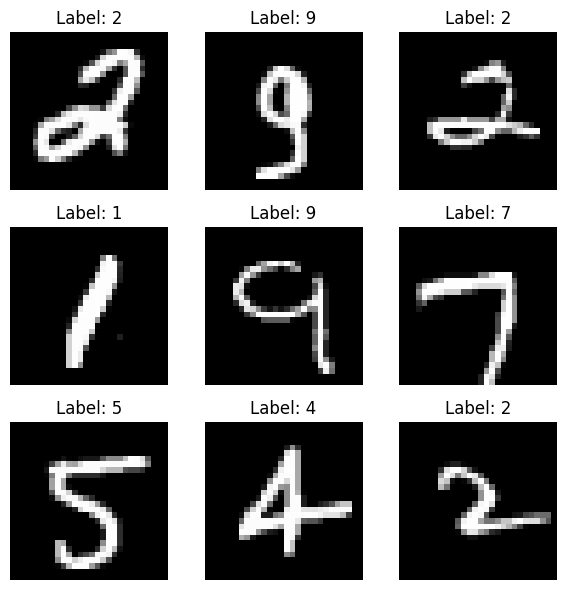

In [ ]:
# random pick 9 indices
import random
indices = random.sample(range(len(train_dataset)), 9)

plt.figure(figsize=(6, 6))
for i, idx in enumerate(indices):
    image, label = train_dataset[idx]

    plt.subplot(3, 3, i + 1)
    # image is [1, 28, 28], so squeeze channel dimension
    plt.imshow(image.squeeze(0), cmap="gray")

    # show the integer label
    plt.title(f"Label: {label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Part 1. Forward Diffusion Process [20/20]

The first step is to implement the forward diffusion process. As introduced in lecture, diffusion gradually destroys the structure of an original sample $x_0$ by repeatedly adding independent Gaussian noise until the sample becomes nearly pure noise at the final timestep.

At each timestep, the forward process is defined as

$$
x_t = \sqrt{1-\beta_t} x_{t-1} + \sqrt{\beta_t} \epsilon_t, \quad \epsilon_t \sim N(0,I).
$$

Equivalently, this means

$$
q(x_t\mid x_{t-1})\sim N(\sqrt{1-\beta_t} x_{t-1}, \beta_t I)
$$

Because the forward process forms a Markov chain and the injected noises are independent across timesteps, we can also write the distribution of $x_t$ directly in terms of the original clean sample $x_0$:

$$
x_t = \bar \alpha_t x_0 + \sqrt{1-\bar \alpha_t} \epsilon_t,\quad \epsilon_t\sim N(0, I)
$$
or, equivalently,
$$
q(x_t\mid x_0) \sim N(\sqrt{\bar a_t} x_0, (1-\bar \alpha_t) I)
$$
where
$$\alpha_t = 1-\beta_t, \quad \bar \alpha_t = \prod_{s=1}^t \alpha_s$$.


### Noise Schedule

Here, the sequence $\{\beta_t\}$ is a user-chosen *hyperparameter* schedule that controls how much noise is added at each timestep. Since $\beta_t$ determines the noise variance, it is often called the **noise/variance schedule**. Once the $\beta_t$ values are chosen, we can compute the corresponding $\alpha_t$ and $\bar{\alpha}_t$, which will be used later in both training and sampling.

In this assignment, for simplicity, we use a **linear beta schedule**, where the $\beta_t$ values increase linearly from a small value to a larger value over time.

In [ ]:
def linear_beta_schedule(
    timesteps: int,
    beta_start: float = 1e-4,
    beta_end: float = 2e-2,
    device: str | torch.device = "cpu",
) -> torch.Tensor:
    """
    Linear beta schedule for DDPM.

    Args:
        timesteps: total number of diffusion steps
        beta_start: initial beta value
        beta_end: final beta value
        device: cpu or cuda

    Returns:
        betas: tensor of shape [T]
    """
    # TODO:
    # return a 1D tensor of length `timesteps`
    # whose values increase linearly from beta_start to beta_end
    raise NotImplementedError

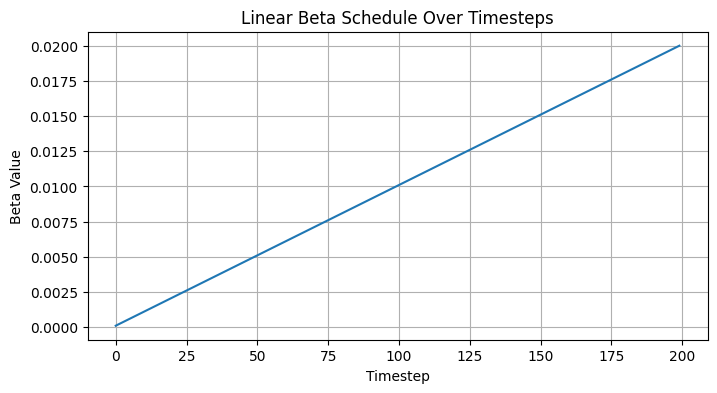

In [ ]:
betas = linear_beta_schedule(timesteps=TIMESTEPS, device=device)

plt.figure(figsize=(8, 4))
plt.plot(range(TIMESTEPS), betas.cpu().numpy())
plt.title("Linear Beta Schedule Over Timesteps")
plt.xlabel("Timestep")
plt.ylabel("Beta Value")
plt.grid(True)
plt.show()

We can see that the noise level starts very small and gradually increases over time, so early timesteps only slightly perturb the image while later timesteps add much stronger noise.

After defining the beta schedule, the next step is to compute $\{\alpha_t\}$ and $\{\bar \alpha_t\}$:

$$\alpha_t = 1-\beta_t, \quad \bar \alpha_t = \prod_{s=1}^t \alpha_s.$$

In practice, instead of storing only $\alpha_t$ and $\bar{\alpha}_t$, we usually precompute the following two quantities:

$$
\sqrt{\bar \alpha_t},
\quad
\sqrt{1-\bar \alpha_t},
$$

since they appear directly in the closed-form expression

$$
x_t = \bar \alpha_t x_0 + \sqrt{1-\bar \alpha_t} \epsilon_t,\quad \epsilon_t\sim N(0, I)
$$

The function below takes the beta schedule as input, computes $\alpha_t$ and the cumulative product $\bar{\alpha}_t$, and then returns the two precomputed tensors needed.

In [ ]:
def prepare_diffusion_schedule(betas: torch.Tensor):
    """
    Given betas of shape [T], return the key precomputed tensors
    used in the forward diffusion process.

    Args:
        betas: tensor of shape [T]

    Returns:
        sqrt_alphas_cumprod: shape [T]
        sqrt_one_minus_alphas_cumprod: shape [T]
    """
    # TODO:
    # 1. compute alphas = 1 - betas
    # 2. compute cumulative products of alphas
    # 3. compute sqrt_alphas_cumprod
    # 4. compute sqrt_one_minus_alphas_cumprod
    raise NotImplementedError

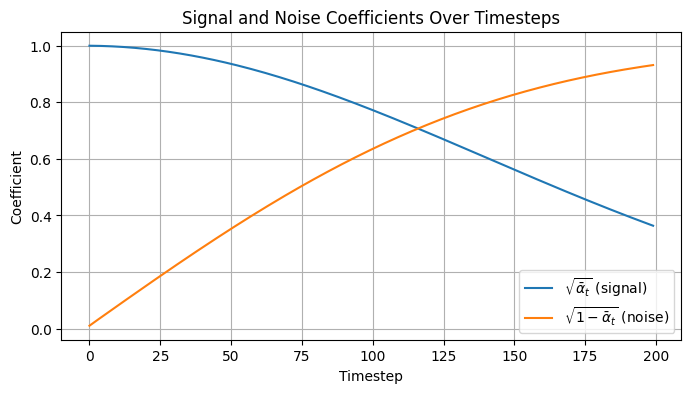

In [ ]:
sqrt_alphas_cumprod, sqrt_one_minus_alphas_cumprod = prepare_diffusion_schedule(betas)

plt.figure(figsize=(8, 4))
plt.plot(range(TIMESTEPS), sqrt_alphas_cumprod.cpu().numpy(), label=r"$\sqrt{\bar{\alpha}_t}$ (signal)")
plt.plot(range(TIMESTEPS), sqrt_one_minus_alphas_cumprod.cpu().numpy(), label=r"$\sqrt{1-\bar{\alpha}_t}$ (noise)")
plt.title("Signal and Noise Coefficients Over Timesteps")
plt.xlabel("Timestep")
plt.ylabel("Coefficient")
plt.legend()
plt.grid(True)
plt.show()

As the timestep $t$ increases, the coefficient of the original signal $x_0$, namely $\sqrt{\bar{\alpha}_t}$, gradually decreases toward $0$. At the same time, the coefficient of the noise term, $\sqrt{1-\bar{\alpha}_t}$, gradually increases toward $1$. Therefore, the noisy sample $x_t$ contains less and less information from the original image and becomes increasingly dominated by Gaussian noise.

$$
x_t \to N(0, I),\quad \text{as}\quad t\to T.
$$


### Direct Forward Noising

Next, implement a function `q_sample()` that directly samples nosiy sample $x_t$ directly from the original $x_0$ at timestep $t$. Instead of simulating the forward process step by step from $x_1$ to $x_{t-1}$, we use the closed-form expression

$$
x_t = \bar \alpha_t x_0 + \sqrt{1-\bar \alpha_t} \epsilon_t,\quad \epsilon_t\sim N(0, I)
$$

This allows us to sample $x_t$ from $x_0$ in a single step, which is much more efficient during training.

Importantly, since we work with mini-batches, different images in the same batch may be assigned different timesteps. Therefore, we first define a small helper function `extract()` that selects the appropriate coefficient (e.g., $\sqrt{\bar \alpha_t}$) for each sample in the batch and reshapes it so it can be broadcast to match the image tensor shape.

In [ ]:
import torch
import matplotlib.pyplot as plt

def extract(a: torch.Tensor, t: torch.Tensor, x_shape: torch.Size) -> torch.Tensor:
    """
    Extract a[t] for each batch element and reshape for broadcasting.
    """
    batch_size = t.shape[0]
    out = a.gather(0, t)
    return out.reshape(batch_size, *([1] * (len(x_shape) - 1)))

def q_sample(
    x0: torch.Tensor,
    t: torch.Tensor,
    sqrt_alphas_cumprod: torch.Tensor,
    sqrt_one_minus_alphas_cumprod: torch.Tensor,
    noise: torch.Tensor | None = None,
) -> torch.Tensor:
    """
    Sample x_t directly from x_0 using the closed-form forward diffusion formula.

    Args:
        x0: clean image batch of shape [B, C, H, W]
        t: timestep tensor of shape [B]
        sqrt_alphas_cumprod: shape [T]
        sqrt_one_minus_alphas_cumprod: shape [T]
        noise: optional Gaussian noise of same shape as x0

    Returns:
        xt: noisy image batch of shape [B, C, H, W]
    """
    if noise is None:
        noise = torch.randn_like(x0)

    # TODO:
    # 1. extract sqrt(alpha_bar_t) for each sample in the batch
    # 2. extract sqrt(1 - alpha_bar_t) for each sample in the batch
    # 3. combine x0 and noise using the forward diffusion formula
    raise NotImplementedError


### Visualize the Forward Noising Process

Now that we have defined the diffusion schedule, let us visualize how the forward diffusion process gradually corrupts an image over time. We take several MNIST images and generate their noisy versions at different timesteps. This helps us directly observe how the original digit structure is slowly destroyed as more Gaussian noise is added.

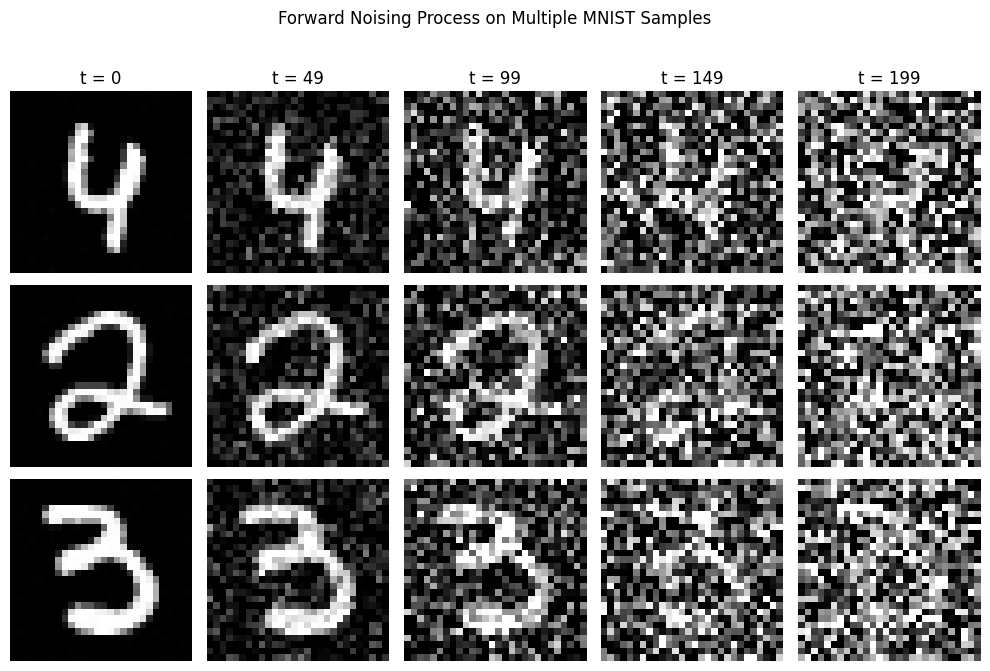

In [ ]:
import random

betas = linear_beta_schedule(timesteps=TIMESTEPS, device=device)
sqrt_alphas_cumprod, sqrt_one_minus_alphas_cumprod = prepare_diffusion_schedule(betas)

# choose timesteps to visualize
timesteps_to_show = torch.linspace(0, TIMESTEPS - 1, steps=5, dtype=torch.long).tolist()

# randomly pick several samples
num_samples = 3
indices = random.sample(range(len(train_dataset)), num_samples)

plt.figure(figsize=(2 * len(timesteps_to_show), 2.2 * num_samples))

for row, idx in enumerate(indices):
    x0, label = train_dataset[idx]
    x0 = x0.unsqueeze(0).to(device)   # shape: [1, 1, 28, 28]

    for col, t_val in enumerate(timesteps_to_show):
        t = torch.tensor([t_val], device=device, dtype=torch.long)

        xt = q_sample(
            x0=x0,
            t=t,
            sqrt_alphas_cumprod=sqrt_alphas_cumprod,
            sqrt_one_minus_alphas_cumprod=sqrt_one_minus_alphas_cumprod,
        )

        # convert from [-1, 1] back to [0, 1] for display
        img = ((xt[0].detach().cpu() + 1) / 2).clamp(0, 1)

        plt.subplot(num_samples, len(timesteps_to_show), row * len(timesteps_to_show) + col + 1)
        plt.imshow(img.squeeze(0), cmap="gray")

        if row == 0:
            plt.title(f"t = {t_val}")
        if col == 0:
            plt.ylabel(f"label {label}", rotation=0, labelpad=25, va="center")

        plt.axis("off")

plt.suptitle("Forward Noising Process on Multiple MNIST Samples", y=1.02)
plt.tight_layout()
plt.show()

## Part 2. Build a Noise Predictor [30/30]

After defining the forward diffusion process, the next step is to train a neural network to reverse it. In particular, during training, the model takes a noisy image $x_t$, then learns to predict the Gaussian noise $\epsilon_t$ that was added to the original $x_0$. In other words, we want to learn a network

$$
  \epsilon_{\theta}(x_t, t)
$$

which maps a noisy image and its timestep to a noise prediction.

Remarkably, the timestep $t$ is important because the $x_t$ depends on how much noise has been added. An image at an early timestep still looks close to the original digit, while an image at a late timestep may be almost pure noise. Therefore, the model must use both the noisy image and the timestep as input.


### Timestep Embedding

To represent timestep $t$, we convert each timestep $t$ into a vector representation called a **timestep embedding**. A common choice is to use **sinusoidal embeddings**, which map each timestep to a vector of sine and cosine values at different frequencies. This gives the model a smooth and informative representation of time:

$$
\mathrm{emb}(t)_{2i} = \sin(t/10000^{2i/d}),
\qquad
\mathrm{emb}(t)_{2i+1} = \cos(t/10000^{2i/d}),
\qquad i = 0,1,\dots,\frac{d}{2}-1
$$
where $d$ is the embedding dimension.



In [ ]:
import math
import torch
import torch.nn.functional as F

def timestep_embedding(t: torch.Tensor, dim: int, max_period: int = 10000) -> torch.Tensor:
    """
    Create sinusoidal timestep embeddings.

    Args:
        t: timestep tensor of shape [B]
        dim: embedding dimension
        max_period: controls the minimum frequency

    Returns:
        emb: tensor of shape [B, dim]
    """
    # TODO:
    # 1. compute half = dim // 2
    # 2. create frequency values
    # 3. compute sinusoidal arguments
    # 4. build sine and cosine parts
    # 5. interleave or concatenate them into shape [B, dim] (or [B, dim-1] then pad)
    raise NotImplementedError

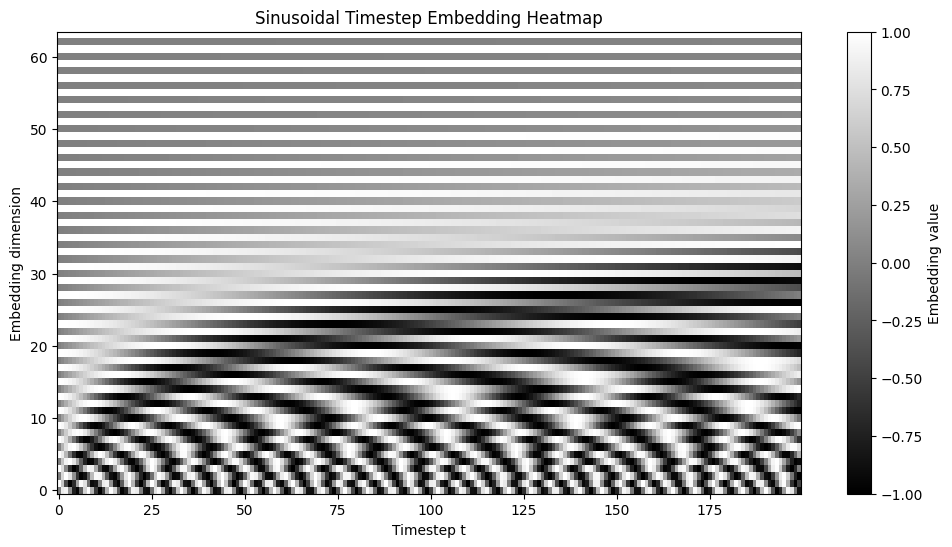

In [ ]:
# timesteps from 0 to 199
t = torch.arange(0, TIMESTEPS, device=device)

# compute embeddings
emb = timestep_embedding(t, dim=TIME_EMB_DIM).detach().cpu()   # shape [200, 32]

# grayscale heatmap: x-axis = time, y-axis = embedding dimension
plt.figure(figsize=(12, 6))
plt.imshow(
    emb.T.numpy(),      # rows = dimensions, cols = timesteps
    aspect="auto",
    origin="lower",
    cmap="gray",
    interpolation="nearest"
)
plt.colorbar(label="Embedding value")
plt.xlabel("Timestep t")
plt.ylabel("Embedding dimension")
plt.title("Sinusoidal Timestep Embedding Heatmap")
plt.show()

### Design a Simple CNN for Noise Prediction

Next, we build a simple convolutional neural network to predict the noise added to a noisy image. The model takes as input the noisy image $x_t$ together with its timestep $t$, and outputs a tensor of the same shape representing the predicted noise.

We use a lightweight CNN. The network consists of several convolutional blocks, each using convolution, GroupNorm, and SiLU activation. To incorporate the timestep information, we first transform the sinusoidal timestep embedding through a *two-layer MLP*, then add it to the intermediate feature maps. In this way, the model can adapt its prediction depending on how much noise is present at timestep $t$.

The final output layer maps the hidden features back to one channel so that the prediction has the same shape as the input image.

In [ ]:
import torch.nn as nn

class ConvBlock(nn.Module):
    """
    A simple convolutional block:
        Conv2d -> GroupNorm -> SiLU
    """
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()

        # TODO:
        # 1. define a 3x3 convolution with padding=1
        # 2. define GroupNorm
        # 3. define SiLU activation
        raise NotImplementedError

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # TODO:
        # apply conv -> norm -> activation
        raise NotImplementedError

Test it with:

In [ ]:
block = ConvBlock(in_channels=1, out_channels=32).to(device)
x_test = torch.randn(4, 1, 28, 28, device=device)
y_test = block(x_test)

print("Input shape :", x_test.shape)
print("Output shape:", y_test.shape)   # expected: [4, 32, 28, 28]

In [ ]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

class SimpleDDPMCNN(nn.Module):
    """
    A simple timestep-conditioned CNN for MNIST diffusion.

    Input:
        x_t: [B, 1, 28, 28]
        t:   [B]

    Output:
        predicted noise: [B, 1, 28, 28]
    """
    def __init__(
        self,
        in_channels: int = 1,
        hidden_channels: int = 64,
        time_emb_dim: int = 128,
    ):
        super().__init__()

        # Time embedding MLP
        self.time_mlp = nn.Sequential(
            # TODO: define a small MLP for time embedding
        )

        # CNN blocks
        # TODO: define several ConvBlocks
        self.block1 =
        self.block2 =
        self.block3 =
        self.block4 =

        # Output layer predicts noise with same shape as input
        # TODO: define a final output convolution mapping hidden_channels -> in_channels
        self.out =

        self.time_emb_dim = time_emb_dim
        self.hidden_channels = hidden_channels

    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: noisy image x_t, shape [B, 1, 28, 28]
            t: timestep tensor, shape [B]

        Returns:
            predicted noise, shape [B, 1, 28, 28]
        """
        # 1) build timestep embedding
        # TODO: compute timestep embedding using timestep_embedding(...)
        #       pass it through the time MLP
        #       reshape it to [B, hidden_channels, 1, 1]
        temb =        # [B, time_emb_dim]
        temb =        # [B, hidden_channels]
        temb =        # [B, hidden_channels, 1, 1]

        # 2) CNN with time conditioning
        # TODO: apply CNN blocks
        #       add timestep features to intermediate feature maps
        h =

        # 3) predict noise
        return self.out(h)

## Part 3. Train with the Simple DDPM loss [20/20]

After building the noise prediction network, we now train it using the standard DDPM objective.

The training processure at training step consists of the following:
1. Sample a data $x_0$ from MNIST
2. Sample a ime $t\sim \text{Uniform}\{1,...,T\}$
3. Sample a Gaussian noise $\epsilon\sim N(0,I)$
4. form $x_t$
5. predict $\bar \epsilon = \epsilon_{\theta}(x_t,t)$
6. Combine the MSE $\|\epsilon - \bar \epsilon\|^2$ and update parameters $\theta$

To make the implementation cleaner and easier to reuse, we split the training code into two functions. The first function `train_one_epoch()` performs one epoch of training. The second function `train_ddpm()` repeatedly calls `train_one_epoch()` for multiple epochs and records the average loss at each epoch.

In [ ]:
def predict_noise(model, x_t, t):
    """
    Run the noise-prediction model and always return a tensor.
    Works for both a custom PyTorch model and diffusers.UNet2DModel.
    """
    output = model(x_t, t)
    return output.sample if hasattr(output, "sample") else output

def train_one_epoch(
    model,
    dataloader,
    optimizer,
    sqrt_alphas_cumprod,
    sqrt_one_minus_alphas_cumprod,
    timesteps,
    device,
):
    model.train()
    running_loss = 0.0
    num_batches = 0

    pbar = tqdm(dataloader)

    for x0, _ in pbar:
        x0 = x0.to(device)
        batch_size = x0.shape[0]

        # 1. sample a random timestep for each image
        # TODO: sample timestep tensor t of shape [B]
        t =

        # 2. sample Gaussian noise
        # TODO: sample Gaussian noise with torch.randn_like(x0)
        noise =

        # 3. construct x_t
        # TODO: construct xt using q_sample(...)
        xt = q_sample(

        )

        # 4. predict the noise
        # TODO: predict noise using predict_noise(...)
        noise_pred =

        # 5. compute simple DDPM loss
        # TODO: compute MSE loss against the true noise
        loss = F.mse_loss(noise_pred, noise)

        # TODO: zero gradients, backpropagate, and step the optimizer

        # TODO: accumulate the loss


        num_batches += 1
        pbar.set_postfix(loss=loss.item())

    return running_loss / num_batches

We then wrap one training epoch into the full DDPM training procedure:

In [ ]:
def train_ddpm(
    model,
    dataloader,
    optimizer,
    sqrt_alphas_cumprod,
    sqrt_one_minus_alphas_cumprod,
    timesteps,
    epochs,
    device,
):
    """
    Train the DDPM model for multiple epochs.

    Returns:
        losses_per_epoch: list of average training losses
    """
    losses_per_epoch = []

    for epoch in range(epochs):
        # TODO: call train_one_epoch(...) to compute the avg_loss
        avg_loss =


        losses_per_epoch.append(avg_loss)
        print(f"Epoch {epoch+1}/{epochs}: average loss = {avg_loss:.6f}")

    return losses_per_epoch

### Initialize the Model and Training Setup

We are now ready to initialize the diffusion schedule, the noise prediction network, and the optimizer. To keep the experiment settings clear and easy to track, it is also helpful to print the main configuration values before training. This makes it easier to review the setup later when comparing different runs.

In [ ]:
from torch.optim import AdamW
from tqdm.auto import tqdm

print("Using device:", device)

betas = linear_beta_schedule(timesteps=TIMESTEPS, device=device)
sqrt_alphas_cumprod, sqrt_one_minus_alphas_cumprod = prepare_diffusion_schedule(betas)

model = SimpleDDPMCNN(
    in_channels=IN_CHANNELS,
    hidden_channels=HIDDEN_CHANNELS,
    time_emb_dim=TIME_EMB_DIM,
).to(device)

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)

print("\nTraining setup:")
print(f"  Image size        : {IMG_SIZE} x {IMG_SIZE}")
print(f"  Batch size        : {BATCH_SIZE}")
print(f"  Timesteps         : {TIMESTEPS}")
print(f"  Epochs            : {EPOCHS}")
print(f"  Learning rate     : {LEARNING_RATE}")
print(f"  In channels       : {IN_CHANNELS}")
print(f"  Hidden channels   : {HIDDEN_CHANNELS}")
print(f"  Time emb dim      : {TIME_EMB_DIM}")
print(f"  Optimizer         : AdamW")
print(f"  Model             : SimpleDDPMCNN")

Using device: cuda

Training setup:
  Image size        : 28 x 28
  Batch size        : 128
  Timesteps         : 200
  Epochs            : 10
  Learning rate     : 0.001
  In channels       : 1
  Hidden channels   : 64
  Time emb dim      : 64
  Optimizer         : AdamW
  Model             : SimpleDDPMCNN


In [ ]:
losses_per_epoch = train_ddpm(
    model=model,
    dataloader=train_loader,
    optimizer=optimizer,
    sqrt_alphas_cumprod=sqrt_alphas_cumprod,
    sqrt_one_minus_alphas_cumprod=sqrt_one_minus_alphas_cumprod,
    timesteps=TIMESTEPS,
    epochs=EPOCHS,
    device=device,
)

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch 1/10: average loss = 0.097119


  0%|          | 0/469 [00:00<?, ?it/s]

Epoch 2/10: average loss = 0.064366


  0%|          | 0/469 [00:00<?, ?it/s]

...

Epoch 8/10: average loss = 0.055156


  0%|          | 0/469 [00:00<?, ?it/s]

Epoch 9/10: average loss = 0.054587


  0%|          | 0/469 [00:00<?, ?it/s]

Epoch 10/10: average loss = 0.054434


We can now visualize the training loss over epochs:

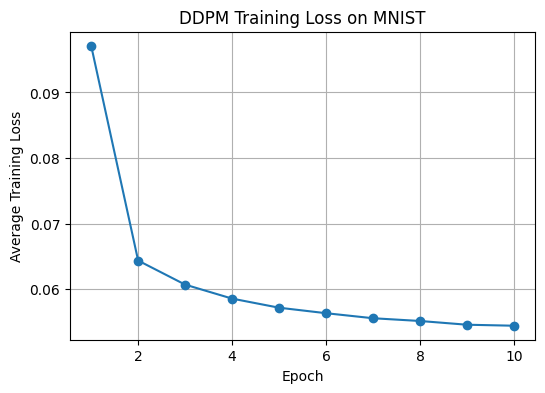

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(losses_per_epoch) + 1), losses_per_epoch, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Average Training Loss")
plt.title("DDPM Training Loss on MNIST")
plt.grid(True)
plt.show()

## Part 4. Reverse Sampling [20/20]

After training the model to predict the noise in a noisy image $x_t$, we can use it to generate new samples.

At sampling time, we start from pure Gaussian noise

$$
x_T \sim N(0, I),
$$

and repeatedly apply the learned reverse denoising step

$$
x_T \to x_{T-1} \to \cdots \to x_0.
$$

At each step, the model predicts the noise in the current image $x_t$, and that prediction is used to move toward a less noisy sample.


### One Reverse Denoising Step

Recall that, in DDPM, the reverse transition is modeled as a Gaussian distribution:

$$
p_{\theta}(x_{t-1}\mid x_t)=N(\mu_{\theta}(x_t),\sigma_t^2 I)
$$


Equivalently, a simple reverse update is

$$
x_{t-1} = \mu_{\theta}(x_{t}) + \sigma_t z,
$$

A simple DDPM reverse update is

$$
x_{t-1}
=
\frac{1}{\sqrt{\alpha_t}}
\left(
x_t-\frac{\beta_t}{\sqrt{1-\bar\alpha_t}}\,\epsilon_\theta(x_t,t)
\right)
+\sigma_t z,
$$

where

- $\epsilon_\theta(x_t,t)$ is the predicted noise,
- $z \sim  N(0,I)$,
- $\sigma_t$ controls the stochasticity of the reverse step.

For this assignment, we use a simple choice

$$
\sigma_t = \sqrt{\beta_t}.
$$

When $t=0$, we do not add extra Gaussian noise.

In [ ]:
import torch
import matplotlib.pyplot as plt


@torch.no_grad()
def p_sample(
    model,
    x_t: torch.Tensor,
    t: torch.Tensor,
    betas: torch.Tensor,
    alphas: torch.Tensor,
    alphas_cumprod: torch.Tensor,
):
    """
    One reverse denoising step: x_t -> x_{t-1}

    Args:
        model: trained noise-prediction model epsilon_theta(x_t, t)
        x_t: current noisy sample, shape [B, C, H, W]
        t: current timestep tensor, shape [B]
        betas: shape [T]
        alphas: shape [T]
        alphas_cumprod: shape [T]

    Returns:
        x_prev: less noisy sample x_{t-1}, shape [B, C, H, W]
    """

    # TODO: extract beta_t, alpha_t, and alpha_bar_t for the current batch


    # TODO: predict noise eps_theta = predict_noise(model, x_t, t)


    # TODO: DDPM reverse mean
    mean =

    # TODO: add noise except for the final step
    noise =

    # TODO: set sigma_t
    sigma_t =

    # TODO: compute x_prev = mean + nonzero_mask * sigma_t * noise

    return x_prev

We now wrap the reverse denoising step into a full sampling function. Starting from random noise, this function repeatedly applies `p_sample()` from timestep $T-1$ down to $0$.

In [ ]:
@torch.no_grad()
def sample_ddpm(
    model,
    image_shape: tuple,
    timesteps: int,
    betas: torch.Tensor,
    device: str | torch.device = "cpu",
    return_all_steps: bool = False,
):
    """
    Generate samples from a trained DDPM model.

    Args:
        model: trained epsilon_theta(x_t, t)
        image_shape: e.g. (16, 1, 28, 28)
        timesteps: total number of diffusion steps
        betas: shape [T]
        device: cpu or cuda
        return_all_steps: whether to store all intermediate x_t

    Returns:
        final samples x_0, or (x_0, trajectory) if return_all_steps=True
    """
    device = torch.device(device)
    model.eval()

    alphas = 1.0 - betas
    alphas_cumprod = torch.cumprod(alphas, dim=0)

    # TODO: initialize x_t as Gaussian noise with shape image_shape
    x_t =

    trajectory = [x_t.detach().cpu()] if return_all_steps else None

    for time_step in reversed(range(timesteps)):
        # TODO: create timestep tensor t of shape [B]
        #       update x_t = p_sample(...)
        #       optionally append x_t to trajectory

    if return_all_steps:
        return x_t, trajectory
    return x_t

### Generate and Visualize Samples

The following code starts from Gaussian noise and iteratively denoises it into MNIST-like images.

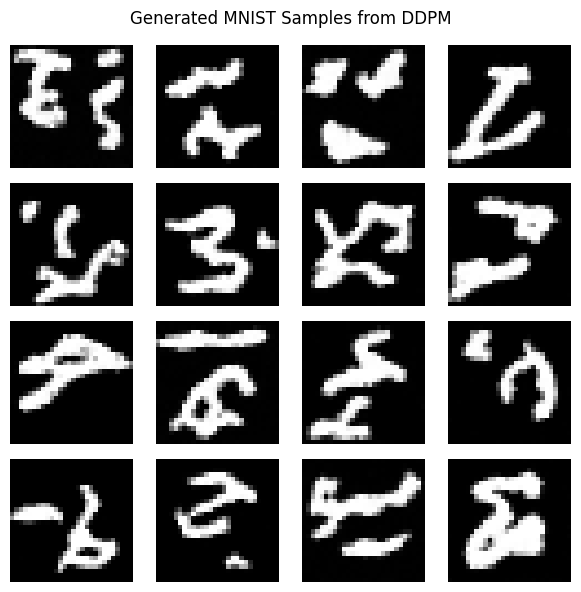

In [ ]:
model.eval()

num_samples = 16
samples = sample_ddpm(
    model=model,
    image_shape=(num_samples, 1, 28, 28),
    timesteps=TIMESTEPS,
    betas=betas,
    device=device,
    return_all_steps=False,
)

# convert from [-1, 1] back to [0, 1] for display
samples = ((samples.detach().cpu() + 1) / 2).clamp(0, 1)

plt.figure(figsize=(6, 6))
for i in range(num_samples):
    plt.subplot(4, 4, i + 1)
    plt.imshow(samples[i].squeeze(0), cmap="gray")
    plt.axis("off")

plt.suptitle("Generated MNIST Samples from DDPM")
plt.tight_layout()
plt.show()

### Visualize the Denoising Process

It is often helpful to inspect the intermediate reverse steps and see how a random noise sample is gradually transformed into a digit. To do this, we generate one sample while storing all intermediate states in the reverse diffusion trajectory, then display a few selected steps.

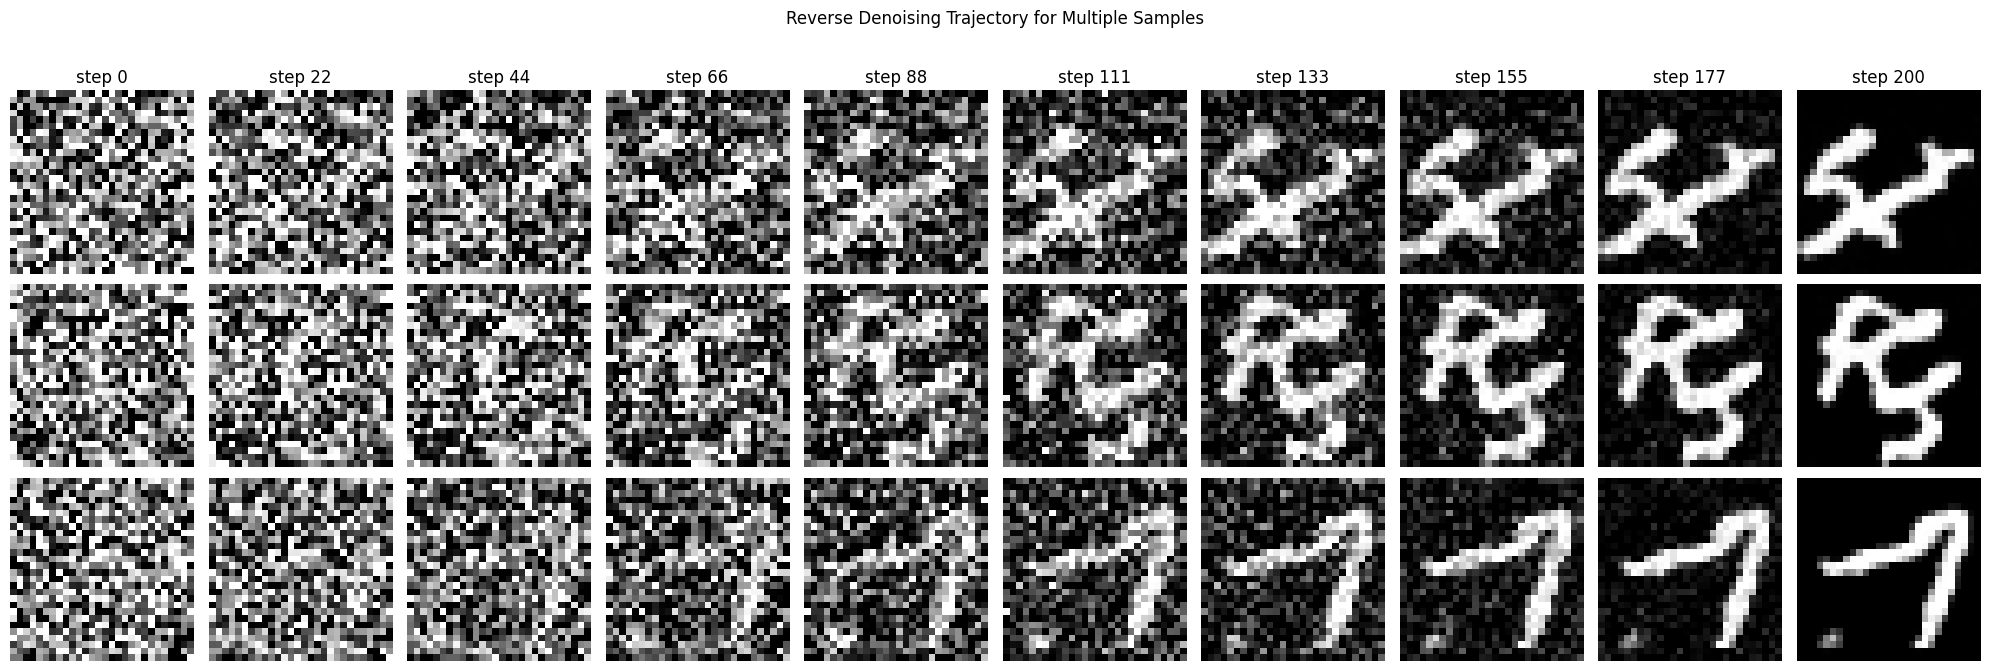

In [ ]:
num_samples = 3
final_sample, trajectory = sample_ddpm(
    model=model,
    image_shape=(num_samples, IN_CHANNELS, IMG_SIZE, IMG_SIZE),
    timesteps=TIMESTEPS,
    betas=betas,
    device=device,
    return_all_steps=True,
)

# choose a few reverse steps to display
steps_to_show = torch.linspace(0, len(trajectory) - 1, steps=10, dtype=torch.long).tolist()

plt.figure(figsize=(2 * len(steps_to_show), 2.2 * num_samples))

for row in range(num_samples):
    for col, idx in enumerate(steps_to_show):
        img = trajectory[idx][row]
        img = ((img + 1) / 2).clamp(0, 1)   # [-1, 1] -> [0, 1]

        plt.subplot(num_samples, len(steps_to_show), row * len(steps_to_show) + col + 1)
        plt.imshow(img.squeeze(0), cmap="gray")

        if row == 0:
            plt.title(f"step {idx}")
        if col == 0:
            plt.ylabel(f"sample {row+1}", rotation=0, labelpad=25, va="center")

        plt.axis("off")

plt.suptitle("Reverse Denoising Trajectory for Multiple Samples", y=1.02)
plt.tight_layout()
plt.show()

### Observations

When inspecting the generated results, you may notice that some samples look like recognizable digits, while others appear blurry and incomplete. This is expected in our current setting, since the goal of this assignment is to understand the basic diffusion pipeline through a simple implementation, rather than to achieve the best possible sample quality.

The current quality is limited by the lightweight CNN, the modest training budget, and the simplified sampling procedure. Possible improvements include
- using a small U-Net,
- tuning the number of timesteps,
- training longer,
- changing the optimizer or learning rate,
- trying a different beta schedule,
- or improving the reverse-step variance.

These extensions are optional and left for further exploration.


## Part 5. Improvements (Optional)

To improve sample quality, we can consider stronger design choices. Two common improvements are using a better noise schedule and using a stronger denoising network.

### Option A: Cosine Noise Schedule

So far, we used a linear beta schedule. Another common choice is a cosine schedule, which often preserves image structure better during diffusion and can lead to improved sample quality.


In [ ]:
import math
import torch

def cosine_beta_schedule(
    timesteps: int,
    s: float = 0.008,
    max_beta: float = 0.999,
    device: str | torch.device = "cpu",
) -> torch.Tensor:
    """
    Cosine beta schedule for DDPM.

    Args:
        timesteps: total number of diffusion steps T
        s: small offset used in the cosine schedule
        max_beta: clip betas to be at most this value
        device: cpu or cuda

    Returns:
        betas: tensor of shape [T]
    """
    device = torch.device(device)

    # t runs from 0 to T
    steps = timesteps + 1
    x = torch.linspace(0, timesteps, steps, device=device)

    alphas_cumprod = torch.cos(
        ((x / timesteps) + s) / (1 + s) * math.pi / 2
    ) ** 2

    # normalize so that alpha_bar_0 = 1
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]

    # convert alpha_bar_t to beta_t
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])

    # clip for numerical stability
    betas = torch.clamp(betas, min=1e-8, max=max_beta)

    return betas

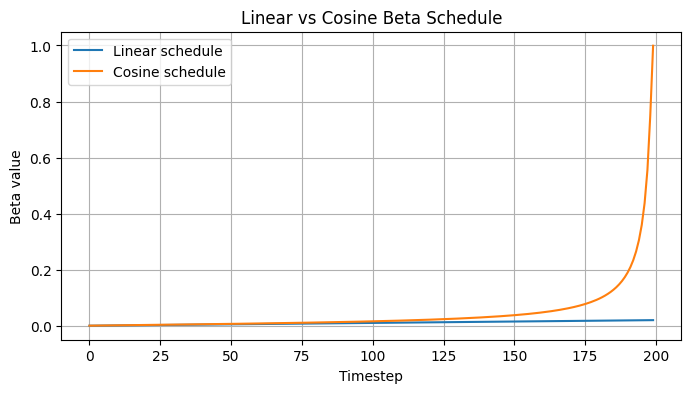

In [ ]:
betas_linear = linear_beta_schedule(timesteps=TIMESTEPS, device=device)
betas_cosine = cosine_beta_schedule(timesteps=TIMESTEPS, device=device)

plt.figure(figsize=(8, 4))
plt.plot(betas_linear.cpu().numpy(), label="Linear schedule")
plt.plot(betas_cosine.cpu().numpy(), label="Cosine schedule")
plt.xlabel("Timestep")
plt.ylabel("Beta value")
plt.title("Linear vs Cosine Beta Schedule")
plt.legend()
plt.grid(True)
plt.show()

### Option B: U-Net with `diffusers`

In [ ]:
!pip install -U diffusers transformers huggingface_hub accelerate

In [ ]:
from diffusers import UNet2DModel
from torch.optim import AdamW

print("Using device:", device)

# betas = cosine_beta_schedule(timesteps=TIMESTEPS, device=device)
betas = linear_beta_schedule(timesteps=TIMESTEPS, device=device)
sqrt_alphas_cumprod, sqrt_one_minus_alphas_cumprod = prepare_diffusion_schedule(betas)

model = UNet2DModel(
    sample_size=IMG_SIZE,
    in_channels=IN_CHANNELS,
    out_channels=IN_CHANNELS,
    layers_per_block=2,
    block_out_channels=(HIDDEN_CHANNELS, HIDDEN_CHANNELS*2),
    down_block_types=(
        "DownBlock2D",
        "DownBlock2D",
    ),
    up_block_types=(
        "UpBlock2D",
        "UpBlock2D",
    ),
).to(device)

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)

print("\nTraining setup:")
print(f"  Image size        : {IMG_SIZE} x {IMG_SIZE}")
print(f"  Batch size        : {BATCH_SIZE}")
print(f"  Timesteps         : {TIMESTEPS}")
print(f"  Epochs            : {EPOCHS}")
print(f"  Learning rate     : {LEARNING_RATE}")
print(f"  In channels       : {IN_CHANNELS}")
print(f"  Optimizer         : AdamW")
print(f"  Model             : UNet2DModel")
print(f"  Layers/block      : 2")
print(f"  Block channels    : (64, 128)")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Using device: cuda

Training setup:
  Image size        : 28 x 28
  Batch size        : 128
  Timesteps         : 200
  Epochs            : 10
  Learning rate     : 0.001
  In channels       : 1
  Optimizer         : AdamW
  Model             : UNet2DModel
  Layers/block      : 2
  Block channels    : (64, 128)


In [ ]:
losses_per_epoch = train_ddpm(
    model=model,
    dataloader=train_loader,
    optimizer=optimizer,
    sqrt_alphas_cumprod=sqrt_alphas_cumprod,
    sqrt_one_minus_alphas_cumprod=sqrt_one_minus_alphas_cumprod,
    timesteps=TIMESTEPS,
    epochs=EPOCHS,
    device=device,
)

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch 1/10: average loss = 0.082361


  0%|          | 0/469 [00:00<?, ?it/s]

Epoch 2/10: average loss = 0.053598


  0%|          | 0/469 [00:00<?, ?it/s]

...

Epoch 8/10: average loss = 0.045179


  0%|          | 0/469 [00:00<?, ?it/s]

Epoch 9/10: average loss = 0.044826


  0%|          | 0/469 [00:00<?, ?it/s]

Epoch 10/10: average loss = 0.044768


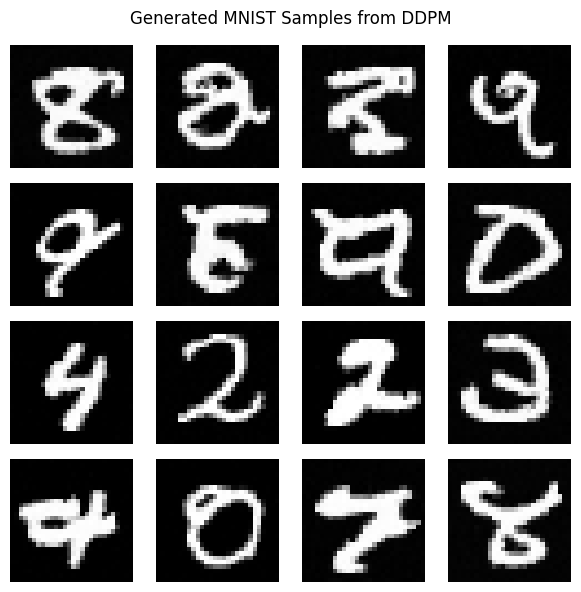

In [ ]:
model.eval()

num_samples = 16
samples = sample_ddpm(
    model=model,
    image_shape=(num_samples, 1, 28, 28),
    timesteps=TIMESTEPS,
    betas=betas,
    device=device,
    return_all_steps=False,
)

# convert from [-1, 1] back to [0, 1] for display
samples = ((samples.detach().cpu() + 1) / 2).clamp(0, 1)

plt.figure(figsize=(6, 6))
for i in range(num_samples):
    plt.subplot(4, 4, i + 1)
    plt.imshow(samples[i].squeeze(0), cmap="gray")
    plt.axis("off")

plt.suptitle("Generated MNIST Samples from DDPM")
plt.tight_layout()
plt.show()

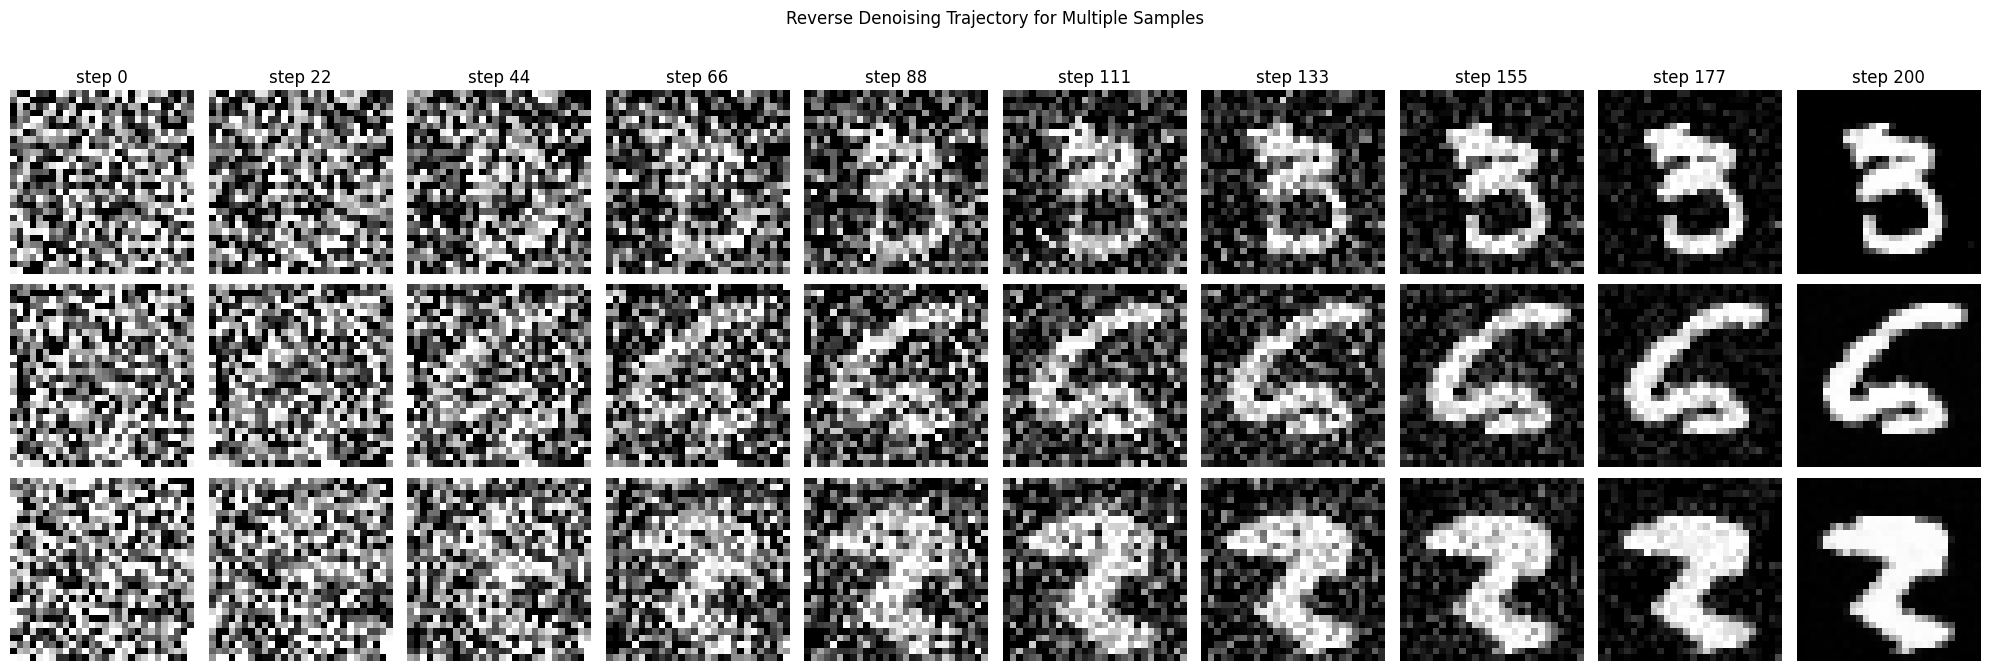

In [ ]:
num_samples = 3
final_sample, trajectory = sample_ddpm(
    model=model,
    image_shape=(num_samples, IN_CHANNELS, IMG_SIZE, IMG_SIZE),
    timesteps=TIMESTEPS,
    betas=betas,
    device=device,
    return_all_steps=True,
)

# choose a few reverse steps to display
steps_to_show = torch.linspace(0, len(trajectory) - 1, steps=10, dtype=torch.long).tolist()

plt.figure(figsize=(2 * len(steps_to_show), 2.2 * num_samples))

for row in range(num_samples):
    for col, idx in enumerate(steps_to_show):
        img = trajectory[idx][row]
        img = ((img + 1) / 2).clamp(0, 1)   # [-1, 1] -> [0, 1]

        plt.subplot(num_samples, len(steps_to_show), row * len(steps_to_show) + col + 1)
        plt.imshow(img.squeeze(0), cmap="gray")

        if row == 0:
            plt.title(f"step {idx}")
        if col == 0:
            plt.ylabel(f"sample {row+1}", rotation=0, labelpad=25, va="center")

        plt.axis("off")

plt.suptitle("Reverse Denoising Trajectory for Multiple Samples", y=1.02)
plt.tight_layout()
plt.show()

<!-- Most diffusion models use architectures that are some variant of a [U-net](https://arxiv.org/abs/1505.04597) and that's what we'll use here.

![](https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/unet-model.png)

In a nutshell:
- the model has the input image go through several blocks of ResNet layers which halves the image size by 2
- then through the same number of blocks that upsample it again.
- there are skip connections linking the features on the downample path to the corresponsding layers in the upsample path.

A key feature of this model is that it predicts images of the same size as the input, which is exactly what we need here.

Diffusers provides us a handy `UNet2DModel` class which creates the desired architecture in PyTorch.

Let's create a U-net for our desired image size.
Note that `down_block_types` correspond to the downsampling blocks (green on the diagram above), and `up_block_types` are the upsampling blocks (red on the diagram): -->
